In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, Ridge, LassoCV, ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import *
from sklearn.datasets import fetch_california_housing, make_regression

### Zadanie 7

In [2]:
housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
alphas = np.logspace(-4, 4, 100)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
y_pred = ridge_cv.predict(X_test_scaled)
ridge_cv.alpha_

np.float64(0.0001)

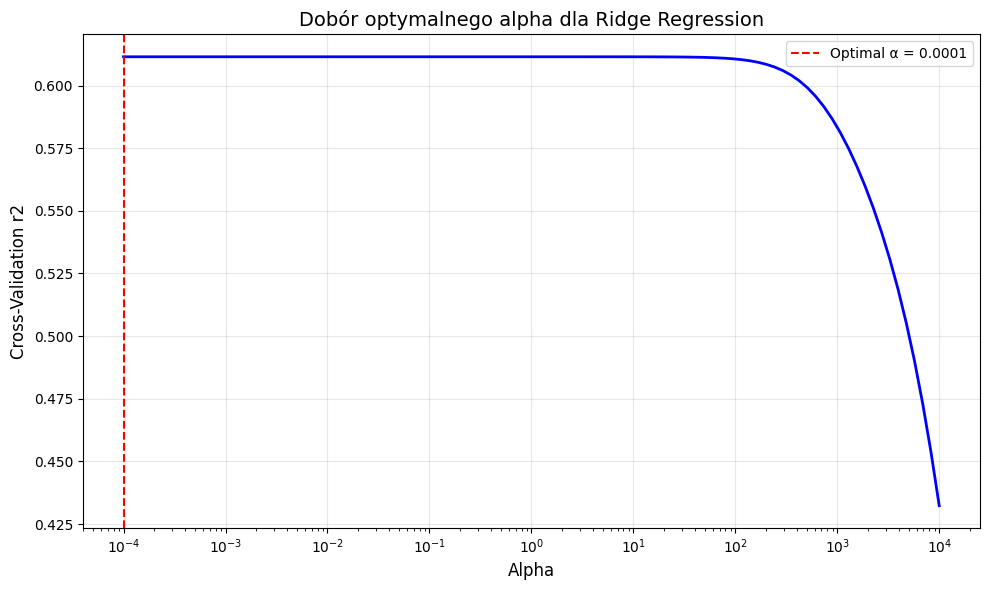

In [3]:
cv_scores = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())
cv_scores = np.array(cv_scores)

plt.figure(figsize=(10, 6))
plt.plot(alphas, cv_scores, 'b-', linewidth=2)
plt.axvline(x=ridge_cv.alpha_, color='red', linestyle='--',
label=f'Optimal α = {ridge_cv.alpha_:.4f}')
plt.xscale('log')
plt.xlabel('Alpha', fontsize=12)
plt.ylabel('Cross-Validation r2', fontsize=12)
plt.title('Dobór optymalnego alpha dla Ridge Regression', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Zadanie 8

In [4]:
lasso_cv = LassoCV(cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)

coef = pd.Series(lasso_cv.coef_, index=housing.feature_names, name="coef")
df = coef.to_frame().sort_values("coef")
print(f'Optymalne alpha: {lasso_cv.alpha_:.4f}\n')
print(f'Cechy wyzerowane:\n {df[np.abs(df.coef) < 1e-6]}\n{(coef == 0.0).sum()}\n')
print(f'Cechy aktywne:\n {df[np.abs(df.coef) > 1e-6]}')


Optymalne alpha: 0.0342

Cechy wyzerowane:
            coef
AveBedrms   0.0
1

Cechy aktywne:
                 coef
Latitude   -0.331026
Longitude  -0.330716
AveOccup   -0.003231
Population  0.000002
AveRooms    0.002123
HouseAge    0.011470
MedInc      0.384305


### Zadanie 12

In [5]:
mk_data = make_regression(n_samples=500, n_features=20, n_informative=10, n_targets=1, noise=10, random_state=42)

def modeler(dataset, dataset_name):
    if isinstance(dataset, tuple):
        Xm, ym = dataset
    else:
        Xm, ym = dataset.data, dataset.target

    Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    Xm_train = scaler.fit_transform(Xm_train)
    Xm_test = scaler.transform(Xm_test)

    alphas = np.logspace(-5, 5, 100)
    models = {
        'RidgeCV': RidgeCV(alphas=alphas,cv=5, scoring='neg_mean_squared_error'),
        'LassoCV': LassoCV(cv=5),
        'ElasticNetCV': ElasticNetCV(alphas=alphas, cv=5, l1_ratio=0.5)
    }

    results = {}
    for k, v in models.items():
        v.fit(Xm_train, ym_train)
        ym_pred = v.predict(Xm_test)
        r2 = r2_score(ym_test, ym_pred)
        coef = v.coef_
        results[f'{k}_r2'] = [r2]
        results[f'{k}_non_0_feat'] = (coef != 0).sum()

    return pd.DataFrame(results, index=[dataset_name])

df = modeler(mk_data, 'make_regression')
pd.concat([df, modeler(housing, 'california_housing')])



,RidgeCV_r2,RidgeCV_non_0_feat,LassoCV_r2,LassoCV_non_0_feat,ElasticNetCV_r2,ElasticNetCV_non_0_feat
make_regression,0.994805,20,0.994912,15,0.994794,20
california_housing,0.575791,8,0.576650,8,0.576191,8
